Producing a Sky Scan with IceCube Public 14-year data
===

This tutorial shows how to produce a Sky scan using the IceCube 14-year public data with SkyLLH.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append("/Users/amithan/skyllh_14/skyllh")

First we have to create a configuration instance.

In [3]:
from skyllh.core.config import Config
cfg = Config()

Importing dataset definition of the public 14-year point-source data set and we can get a list of data sets via the access operator ``[dataset1, dataset2, ...]`` of the ``dsc`` instance:  For more details on the ``create_dataset_collection`` function see 'url'

In [ ]:
from skyllh.datasets.i3.PublicData_14y_ps import create_dataset_collection

dsc = create_dataset_collection(
    cfg=cfg,
    base_path='/Users/amithan/Downloads/',
    sub_path_fmt='PublicData_14y',
)

print(dsc.dataset_names)
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I-XI']

['IC40', 'IC59', 'IC79', 'IC86_I', 'IC86_I-XI', 'IC86_II', 'IC86_III', 'IC86_IV', 'IC86_IX', 'IC86_V', 'IC86_VI', 'IC86_VII', 'IC86_VIII', 'IC86_X', 'IC86_XI']


The analysis used for the published PRL results is referred in SkyLLH as "*traditional point-source analysis*" and is pre-defined:

In [6]:
from skyllh.core.source_model import PointLikeSource
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis

Defining the Source: Here we use NGC 1068 as the source

Once the source is defined the ``create_analysis`` function can create the analysis instance

In [7]:
src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(
    ra=np.radians(src_ra),
    dec=np.radians(src_dec)
)

ana = create_analysis(
    cfg=cfg,
    datasets=datasets,
    source=source
)

100%|██████████| 136/136 [00:00<00:00, 845.70it/s]


## Unblinding the data

After creating the analysis instance we can unblind the data for the choosen source. Hence, we initialize the analysis with a trial of the experimental data, maximize the log-likelihood ratio function for all given experimental data events, and calculate the test-statistic value. The analysis instance has the method ``unblind`` that can be used for that. This method requires a ``RandomStateService`` instance in case the minimizer does not succeed and a new set of initial values for the fit parameters need to get generated.

In [8]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(3090)
TS, bestfit_params, minimizer_status = ana.unblind(rss)
ns_bf = bestfit_params['ns']
gamma_bf = bestfit_params['gamma']
print(f"Unblinded results: TS={TS:.2f}, ns={ns_bf:.2f}, gamma={gamma_bf:.2f}")
print(f"Minimizer status: {minimizer_status}")

Unblinded results: TS=29.15, ns=80.09, gamma=3.21
Minimizer status: {'grad': array([-3.62369895e-06, -2.31360821e-04]), 'task': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH', 'funcalls': 13, 'nit': 10, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 13}


Producing a Sky Scan near the source
===

A Sky Scan is done over a patch near the source coordinates. 

The ``change_source`` property of the ``Analysis`` instance allows us to do the scan by reinitializing for every new sky coordinates in the scan

``change_source`` method allows to update all is necessary without having to re-initialize the entire analysis instance. One could obtain the same result by re-instantiating a new analysis at each point in the sky, which would be much slower. ``change_source`` is an optimized way to carry this out. 

In [9]:
# Produce a little skyscan around the source location

src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

ra_min = src_ra - 1.0
ra_max = src_ra + 1.0
dec_min = src_dec - 1.0
dec_max = src_dec + 1.0

nbins = 50
edges_x = np.linspace(ra_min, ra_max, nbins+1)
edges_y = np.linspace(dec_min, dec_max, nbins+1)
centers_x = 0.5 * (edges_x[1:]+edges_x[:-1])
centers_y = 0.5 * (edges_y[1:]+edges_y[:-1])

# Initialize the results arrays
results_ts = np.zeros((nbins, nbins), dtype=float)
results_p = np.zeros((nbins, nbins), dtype=float)
results_ns = np.zeros((nbins, nbins), dtype=float)
results_g = np.zeros((nbins, nbins), dtype=float)

for i, ra in enumerate(centers_x):
    for j, dec in enumerate(centers_y):
        # Change source position to evaluate the likelihood
        src_dec = np.radians(dec)
        src_ra = np.radians(ra)
        source = PointLikeSource(src_ra, src_dec)
        ana.change_source(source, update_detsigyield_service=False)

        # Unblind the new position
        rss=RandomStateService(3090)
        (TS, fitparam_dict, status) = ana.unblind(rss)
        results_ts[i, j] = TS
        # results_p[i, j] = ts_to_pvalue.get_pvalue(TS, src_dec, gamma=gamma)
        results_ns[i, j] = fitparam_dict['ns']
        results_g[i, j] = fitparam_dict['gamma']

The contours are computed assuming that the Wilks theorem holds true. That is the TS distribution follows the $\chi^2$ distribution with 2 degrees of freedom

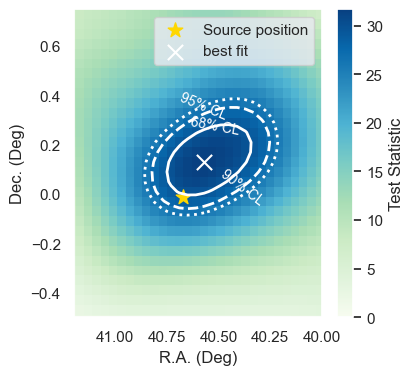

In [32]:
from scipy.stats import chi2
ts_max = results_ts.max()
chi2_68_quantile = ts_max - chi2.ppf(0.68, df=2)
chi2_90_quantile = ts_max - chi2.ppf(0.90, df=2)
chi2_95_quantile = ts_max - chi2.ppf(0.95, df=2)

idx = np.unravel_index(results_ts.argmax(), results_ts.shape)
best_dec = centers_y[idx[0]]
best_ra  = centers_x[idx[1]]

fig,ax = plt.subplots(figsize=(4,4))
X, Y = np.meshgrid(centers_x, centers_y)

src_ra = 40.67  # degrees
src_dec = -0.01

im = ax.pcolormesh(centers_x, centers_y, results_ts, cmap='GnBu')
ax.invert_xaxis()
contour_68 = ax.contour(centers_x, centers_y, results_ts, levels=[chi2_68_quantile],
           colors='w', linestyles='-', linewidths=2)
contour_90 = ax.contour(centers_x, centers_y, results_ts, levels=[chi2_90_quantile],
           colors='w', linestyles='--', linewidths=2)
contour_95 = ax.contour(centers_x, centers_y, results_ts, levels=[chi2_95_quantile],
           colors='w', linestyles=':', linewidths=2)
ax.scatter([src_ra], [src_dec], marker='*', color = 'gold',s=120, label='Source position')
ax.scatter([best_ra], [best_dec], marker='x', color = 'w',s=120, label='best fit')


ax.set_ylim(-0.5, 0.75)
ax.set_xlim(40, 41.2)
cbar = plt.colorbar(im)
cbar.set_label('Test Statistic')
plt.xlabel('R.A. (Deg)')
plt.ylabel('Dec. (Deg)')

ax.clabel(contour_68, 
          fmt={chi2_68_quantile: '68% CL'},
          fontsize=10,
          inline=False,        
          inline_spacing=5,   
          manual=[(40.5, 0.2)])

ax.clabel(contour_90, 
          fmt={chi2_90_quantile: '90% CL'},
          fontsize=10,
          inline=False,        
          inline_spacing=5,   
          manual=[(40.1, -0.3)])

ax.clabel(contour_95, 
          fmt={chi2_95_quantile: '95% CL'},
          fontsize=10,
          inline=False,        
          inline_spacing=5,   
          manual=[(40.6, 0.4)])

ax.invert_xaxis()
plt.legend()
plt.show()
